In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)

In [38]:
df = pd.read_csv('Atlantic_South_Korea.csv')

In [39]:
df['date'] = pd.to_datetime(df['date'])

df['song_artist'] = (
    df['song'].str.strip() +
    " - " +
    df['artist'].str.strip()
)

df['duration_min'] = df['duration_ms'] / 60000

print("Rows:", len(df))
print("Unique Songs:", df['song_artist'].nunique())

Rows: 27800
Unique Songs: 541


C:\Users\DELL\AppData\Local\Temp\ipykernel_16244\54490897.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [40]:
daily_count = df.groupby('date').size()

daily_count.describe()

count    555.000000
mean      50.090090
std        2.122382
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max      100.000000
dtype: float64

In [41]:
daily_count = df.groupby('date').size()

daily_count.describe()

count    555.000000
mean      50.090090
std        2.122382
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max      100.000000
dtype: float64

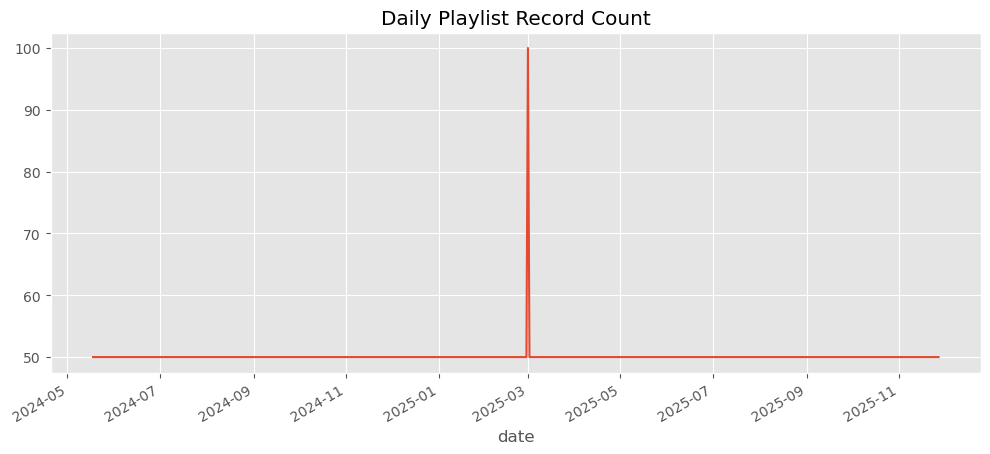

In [42]:
plt.figure(figsize=(12,5))
daily_count.plot()
plt.title("Daily Playlist Record Count")
plt.show()

In [43]:
df.isnull().sum()

date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
song_artist        0
duration_min       0
dtype: int64

In [44]:
reentry_results = []

for song, group in df.groupby("song_artist"):

    group = group.sort_values("date")

    dates = group["date"].drop_duplicates().tolist()

    re_entries = 0
    gaps = []

    for i in range(1, len(dates)):

        gap = (dates[i] - dates[i-1]).days

        if gap > 1:
            re_entries += 1
            gaps.append(gap)

    reentry_results.append([
        song,
        re_entries,
        np.mean(gaps) if len(gaps)>0 else 0,
        max(gaps) if len(gaps)>0 else 0
    ])

reentry_df = pd.DataFrame(
    reentry_results,
    columns=[
        "song_artist",
        "re_entries",
        "avg_gap_days",
        "max_gap_days"
    ]
)

reentry_df.head()

,song_artist,re_entries,avg_gap_days,max_gap_days
0,1-800-hot-n-fun - LE SSERAFIM,0,0.0,0
1,24YB (Intro) - YANGHONGWON,0,0.0,0
2,3D (Alternate Ver.) - Jung Kook & Jack Harlow,0,0.0,0
3,3D (Justin Timberlake Remix) - Jung Kook & Jus...,1,6.0,6
4,3D (feat. Jack Harlow) (Alternate Ver.) - Jung...,0,0.0,0


In [45]:
top_reentry = reentry_df.sort_values(
    "re_entries",
    ascending=False
)

top_reentry.head(20)

,song_artist,re_entries,avg_gap_days,max_gap_days
318,"Our Blues, Our Life - Lim Young Woong",31,3.967742,20
110,Ditto - NewJeans,27,7.037037,28
12,A bientot - Lim Young Woong,24,7.166667,48
306,New Jeans - NewJeans,23,9.260870,63
209,Interlude : Dive - Jimin,21,3.095238,7
191,Hype Boy - NewJeans,21,10.190476,50
343,Rainbow - Lim Young Woong,19,3.526316,13
122,ETA - NewJeans,18,8.277778,77
89,Cruel Summer - Taylor Swift,16,13.125000,64
314,OMG - NewJeans,15,14.200000,55


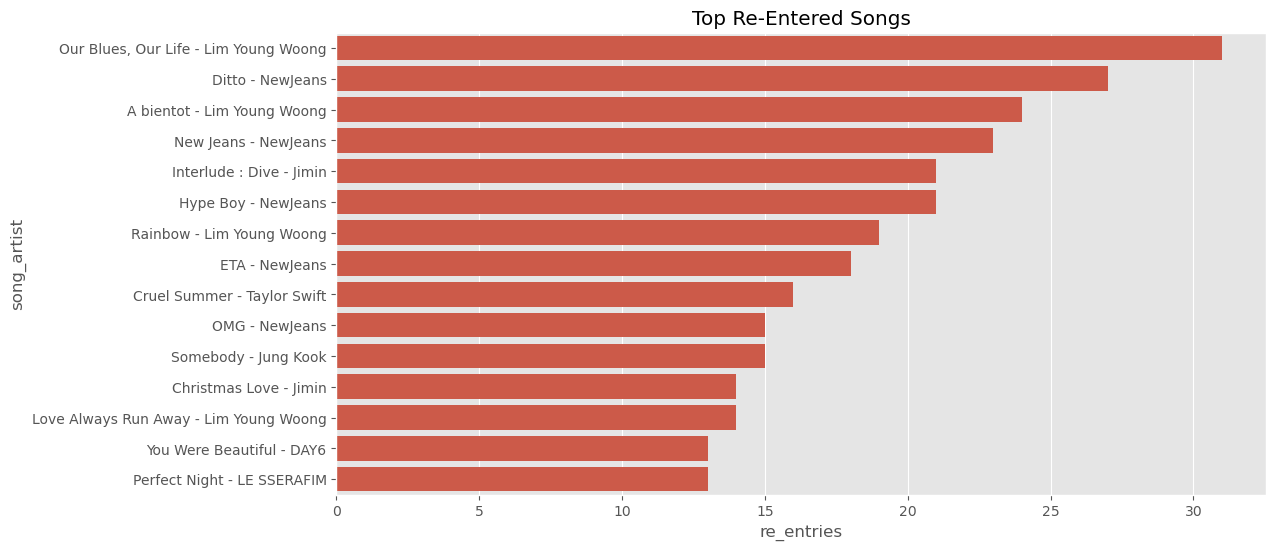

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_reentry.head(15),
    x="re_entries",
    y="song_artist"
)

plt.title("Top Re-Entered Songs")
plt.show()

In [47]:
df = df.sort_values(
    ["song_artist","date"]
)

df['prev_popularity'] = (
    df.groupby('song_artist')['popularity']
    .shift(1)
)

df['popularity_change'] = (
    df['popularity'] -
    df['prev_popularity']
)

In [48]:
df['popularity_growth_rate'] = (
    df['popularity_change']
    /
    df['prev_popularity']
)

df['popularity_growth_rate'] = (
    df['popularity_growth_rate']
    .replace([np.inf,-np.inf],0)
    .fillna(0)
)

In [49]:
df['previous_rank'] = (
    df.groupby('song_artist')['position']
    .shift(1)
)

df['rank_jump'] = (
    df['previous_rank'] -
    df['position']
)

df['rank_jump'] = df['rank_jump'].fillna(0)

In [50]:
df['momentum_spike_score'] = (
    abs(df['rank_jump']) *
    abs(df['popularity_growth_rate'])
)

In [51]:
momentum = (
    df.groupby('song_artist')
      ['momentum_spike_score']
      .max()
      .reset_index()
)

momentum.sort_values(
    "momentum_spike_score",
    ascending=False
).head(20)

,song_artist,momentum_spike_score
274,MEOW - MEOVV,27.151515
220,K-POP - Travis Scott & Bad Bunny & The Weeknd,21.750000
275,MILLION DOLLAR BABY - Tommy Richman,20.666667
60,CARNIVAL - ¥$ & Kanye West & Ty Dolla $ign,9.939394
145,Fast Forward - JEON SOMI,8.152174
182,Here With Me - d4vd,8.043478
257,Lost and Found - KingLee & Lil' Flip,6.333333
486,Warmth - Lim Young Woong,6.285714
100,Dangerous - BOYNEXTDOOR,5.924242
224,Kill It - aespa,5.787234


In [52]:
retention = []

for song, group in df.groupby('song_artist'):

    group = group.sort_values('date')

    days_on_chart = (
        group['date'].max()
        -
        group['date'].min()
    ).days

    retention.append([
        song,
        days_on_chart
    ])

retention_df = pd.DataFrame(
    retention,
    columns=[
        "song_artist",
        "retention_days"
    ]
)

retention_df.head()

,song_artist,retention_days
0,1-800-hot-n-fun - LE SSERAFIM,7
1,24YB (Intro) - YANGHONGWON,2
2,3D (Alternate Ver.) - Jung Kook & Jack Harlow,19
3,3D (Justin Timberlake Remix) - Jung Kook & Jus...,10
4,3D (feat. Jack Harlow) (Alternate Ver.) - Jung...,1


In [53]:
decay = []

for song, group in df.groupby('song_artist'):

    group = group.sort_values("date")

    if len(group) > 1:

        decay_speed = (
            group['position'].iloc[-1]
            -
            group['position'].iloc[0]
        ) / len(group)

    else:
        decay_speed = 0

    decay.append([song, decay_speed])

decay_df = pd.DataFrame(
    decay,
    columns=[
        "song_artist",
        "rank_decay_speed"
    ]
)

In [54]:
album_analysis = (
    df.groupby("album_type")
      .agg({
          "momentum_spike_score":"mean",
          "popularity":"mean"
      })
)

album_analysis

,momentum_spike_score,popularity
album_type,,
album,0.020321,74.199919
compilation,0.000000,27.000000
single,0.018171,78.426797


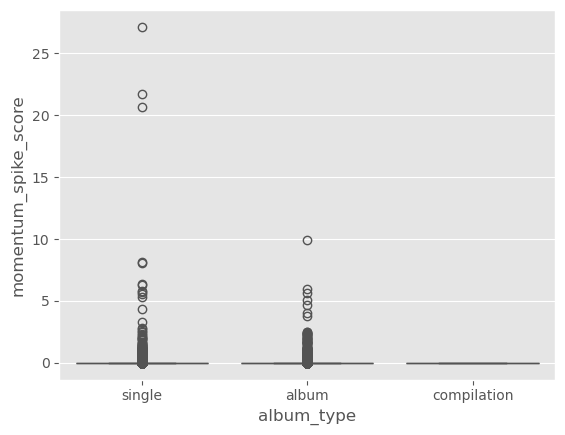

In [55]:
sns.boxplot(
    data=df,
    x="album_type",
    y="momentum_spike_score"
)

plt.show()

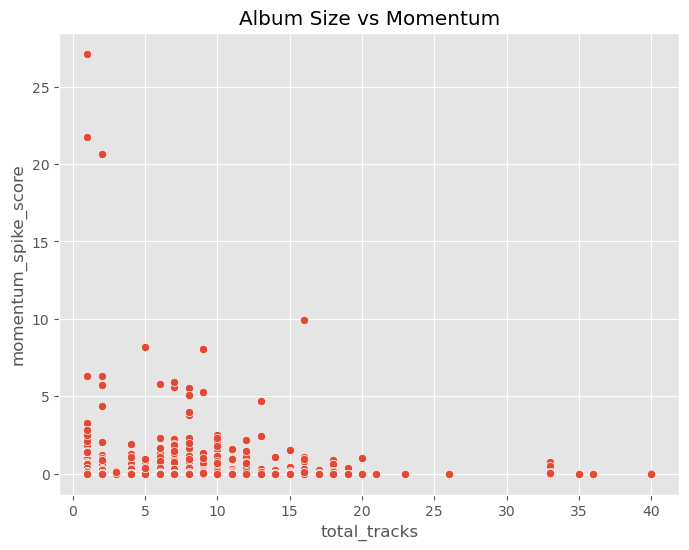

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="total_tracks",
    y="momentum_spike_score"
)

plt.title("Album Size vs Momentum")
plt.show()

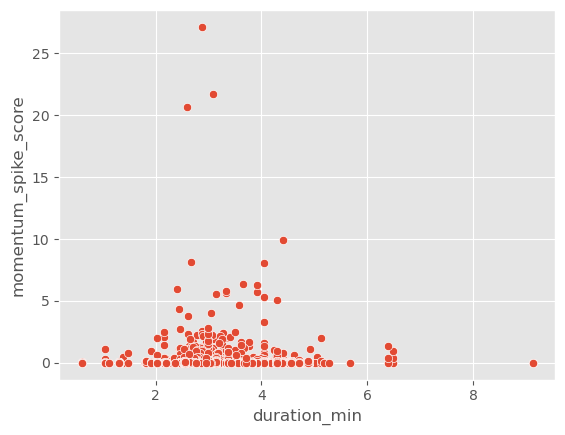

In [57]:
sns.scatterplot(
    data=df,
    x="duration_min",
    y="momentum_spike_score"
)

plt.show()

In [58]:
explicit_analysis = (
    df.groupby("is_explicit")
      .agg({
          "momentum_spike_score":"mean",
          "popularity":"mean"
      })
)

explicit_analysis

,momentum_spike_score,popularity
is_explicit,,
False,0.017957,76.271386
True,0.028166,83.140866


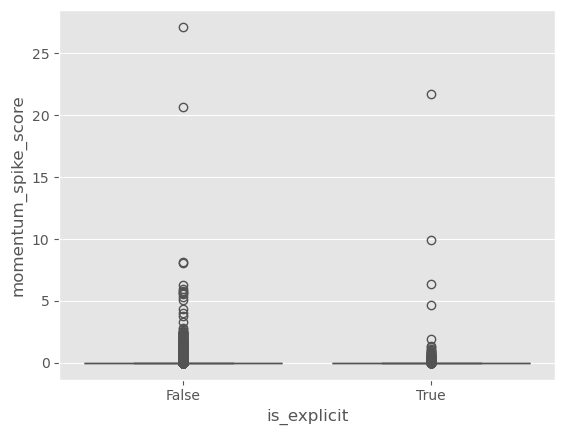

In [59]:
sns.boxplot(
    data=df,
    x="is_explicit",
    y="momentum_spike_score"
)

plt.show()

In [60]:
kpi = (
    reentry_df
    .merge(retention_df,
           on="song_artist")
    .merge(decay_df,
           on="song_artist")
)

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [
    're_entries',
    'avg_gap_days',
    'retention_days'
]

kpi[cols] = scaler.fit_transform(
    kpi[cols]
)

In [62]:
kpi['fandom_intensity_score'] = (

    0.50 * kpi['re_entries']

    +

    0.30 * kpi['retention_days']

    +

    0.20 * (1-kpi['avg_gap_days'])

)

In [63]:
fandom = kpi.sort_values(
    'fandom_intensity_score',
    ascending=False
)

fandom.head(20)

,song_artist,re_entries,avg_gap_days,max_gap_days,retention_days,rank_decay_speed,fandom_intensity_score
318,"Our Blues, Our Life - Lim Young Woong",1.000000,0.007811,20,0.811828,0.030303,0.941986
110,Ditto - NewJeans,0.870968,0.013852,28,0.960573,0.088235,0.920885
306,New Jeans - NewJeans,0.741935,0.018230,63,0.840502,0.135231,0.819472
12,A bientot - Lim Young Woong,0.774194,0.014108,48,0.767025,0.024823,0.814383
191,Hype Boy - NewJeans,0.677419,0.020060,50,0.919355,0.099688,0.810504
209,Interlude : Dive - Jimin,0.677419,0.006093,7,0.729391,0.000000,0.756308
343,Rainbow - Lim Young Woong,0.612903,0.006942,13,0.808244,0.034568,0.747536
122,ETA - NewJeans,0.580645,0.016295,77,0.842294,0.129032,0.739752
314,OMG - NewJeans,0.483871,0.027953,55,0.921147,0.104101,0.712689
89,Cruel Summer - Taylor Swift,0.516129,0.025837,64,0.793907,0.043825,0.691069


In [64]:
artist_fandom = (
    df[['song_artist','artist']]
    .drop_duplicates()
    .merge(
        fandom,
        on='song_artist'
    )
)

artist_fandom = (
    artist_fandom
    .groupby('artist')
    ['fandom_intensity_score']
    .mean()
    .sort_values(ascending=False)
)

artist_fandom.head(20)

artist
Lim Young Woong                                0.468949
Nerd Connection                                0.447433
Mitski                                         0.415367
Jimin                                          0.409742
NewJeans                                       0.405294
Jung Kook                                      0.388751
Charlie Puth                                   0.380669
Jimin & HA SUNG WOON                           0.375113
Jung Kook & BTS                                0.361563
Halsey & SUGA                                  0.347822
Agust D                                        0.341638
Fast & Furious: The Fast Saga & Jimin & BTS    0.334341
Lee Young Ji                                   0.333844
YOASOBI                                        0.320650
Dhruv                                          0.320534
Tommy Richman                                  0.312522
Benson Boone                                   0.311041
ECLIPSE                                  

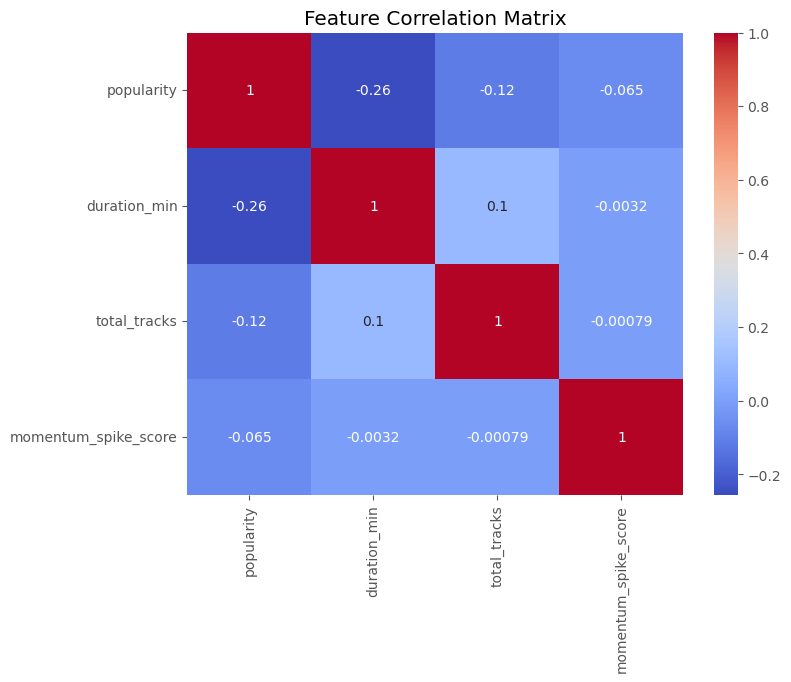

In [65]:
corr_cols = [
    'popularity',
    'duration_min',
    'total_tracks',
    'momentum_spike_score'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

In [66]:
final_leaderboard = (
    fandom.merge(
        momentum,
        on="song_artist"
    )
)

final_leaderboard.sort_values(
    [
        'fandom_intensity_score',
        'momentum_spike_score'
    ],
    ascending=False
).head(25)

,song_artist,re_entries,avg_gap_days,max_gap_days,retention_days,rank_decay_speed,fandom_intensity_score,momentum_spike_score
0,"Our Blues, Our Life - Lim Young Woong",1.000000,0.007811,20,0.811828,0.030303,0.941986,0.229508
1,Ditto - NewJeans,0.870968,0.013852,28,0.960573,0.088235,0.920885,0.214286
2,New Jeans - NewJeans,0.741935,0.018230,63,0.840502,0.135231,0.819472,0.153846
3,A bientot - Lim Young Woong,0.774194,0.014108,48,0.767025,0.024823,0.814383,0.235294
4,Hype Boy - NewJeans,0.677419,0.020060,50,0.919355,0.099688,0.810504,0.303797
5,Interlude : Dive - Jimin,0.677419,0.006093,7,0.729391,0.000000,0.756308,0.341463
6,Rainbow - Lim Young Woong,0.612903,0.006942,13,0.808244,0.034568,0.747536,0.262295
7,ETA - NewJeans,0.580645,0.016295,77,0.842294,0.129032,0.739752,0.313253
8,OMG - NewJeans,0.483871,0.027953,55,0.921147,0.104101,0.712689,0.250000
9,Cruel Summer - Taylor Swift,0.516129,0.025837,64,0.793907,0.043825,0.691069,0.168539
